In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
import sys; sys.path.append("../utils")
from fft_sup_imports import * 
%matplotlib inline
update_rc_params()
import copy

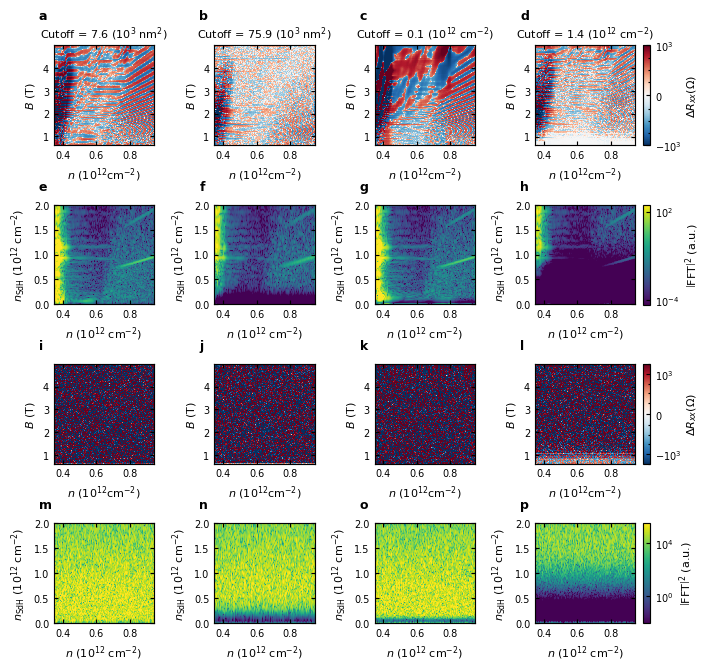

In [ ]:
fig = plt.figure(figsize=(7.5, 7.5))
gs = GridSpec(4,4, wspace=0.6, hspace=0.6)
all_axes = [[plt.subplot(gs[i,j]) for i in range(4)] for j in range(4)]
letters = list(map(chr, range(97, 97+26)))
label_spacer = 0.02
brange = 4.98-0.62
invbRange = 1/0.62 - 1/4.98
detrend_list = [
    {'cutoff': 8/brange, 'order': 4}, # for filtering in B
    {'cutoff': 80/brange, 'order': 4}, # for filtering in B
    {'cutoff': 8/invbRange, 'order': 4}, # for filtering in 1/B
    {'cutoff': 80/invbRange, 'order': 4}  # for filtering in 1/B
]

cutoff_freqs = [
    8/brange * (h/e)*1e15, # units of 10^3 nm^2
    80/brange  * (h/e)*1e15,
    8/invbRange / (h/e)*1e-16, # unit of 10^12 cm^{-2}
    80/invbRange /(h/e)*1e-16,
]
cutoff_freq_str = [
    f"Cutoff = {freq:.1f} {r'($10^{12}$ cm$^{-2}$)' if i//2 else r'($10^3$ nm$^2$)'}" for i, freq in enumerate(cutoff_freqs)
]


norm_list = [norm_lf_delRxx, norm_psd]
# Set up analyzer
analyzer_data = Lf_analysis(1840, 2)
# Set up the noise analyzer
analyzer_noise = copy.deepcopy(analyzer_data)
analyzer_noise.Rxx_raw = np.random.normal(
    np.mean(analyzer_data.Rxx_raw),
    np.std(analyzer_data.Rxx_raw),
    np.shape(analyzer_data.Rxx_raw)
)
norm_psd_noise = colors.LogNorm(vmin=1e-2, vmax=3e5)
norm_delRxx_noise = colors.SymLogNorm(vmin=-1e4, vmax=1e4, linthresh=1)
for i, axes in enumerate(all_axes):
    for j, ax in enumerate(axes):
        pos = ax.get_position()
        
        fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer + (0.015 if j == 0 else 0), letters[4*j+i], fontweight='bold')
        # Do some logic to pick out correct plot type

        params = detrend_list[i]
        analyzer = analyzer_noise if j // 2 else analyzer_data
        if j % 2:
            # Plot FFT
            plot = analyzer.plot_fft_invcm(fig, ax, norm_psd_noise if j // 2 else norm_psd,
                bg_method=detrend_butterworth,                    
                bg_method_params=params,
                padding=1,
                blims=(0.62, 4.98),
                filter_invB = i // 2
            )
            if i == 3:
                cb_width = 0.3 * 3.325/7.5
                cax = fig.add_axes([pos.x1 +0.01, pos.y1 - cb_width,  0.01, cb_width])
                cb = plt.colorbar(plot, cax=cax, ticks = [1, 1e4] if j // 2 else [1e-4, 1e2],\
                                orientation='vertical', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=0.4)
                cb.ax.set_ylabel(r'$\left|\mathrm{FFT}\right|^2$ (a.u.)', labelpad=3)
        else:
            # Plot Del Rxx
            plot = analyzer.plot_lf(fig, ax, norm_delRxx_noise if j // 2 else norm_lf_delRxx,
                bg_method=detrend_butterworth, # No subtraction,                         
                bg_method_params= params, 
                blims=(0.62, 4.98),
                cmap='RdBu_r',
                filter_invB = i // 2
            )
            if j // 2 == 0:
                ax.set_title(
                    cutoff_freq_str[i]
                )
           
            if i == 3:
                cb_width = 0.3 * 3.325/7.5
                cax = fig.add_axes([pos.x1 +0.01, pos.y1 - cb_width,  0.01, cb_width])
                cb = plt.colorbar(plot, cax=cax, ticks = [-1e3, 0, 1e3], \
                                orientation='vertical', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=0.4)
                cb.ax.set_ylabel(r'$\Delta R_{xx} (\Omega)$', labelpad=3)

plt.savefig('figS_FFT_filtering_comp.pdf', dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)